# Transaction Foundation Model on Ray — Part 2: Load & explore the data w/ Ray Data

<div align="left">
  <a target="_blank" href="https://console.anyscale.com/template-preview/fintech_transaction_fm"><img src="https://img.shields.io/badge/🚀 Run_on-Anyscale-9hf"></a>&nbsp;
  <a href="https://github.com/anyscale/templates/tree/main/templates/fintech_transaction_fm" role="button"><img src="https://img.shields.io/static/v1?label=&message=View%20On%20GitHub&color=586069&logo=github&labelColor=2f363d"></a>&nbsp;
</div>

**⏱️ Time to complete**: ~15 min (most of it the one-time dataset download + normalize)


---

Part 1 laid out the plan. Here the work starts: download the IBM TabFormer benchmark, look at what is in it, and build the temporal train/val/test split that every later notebook reads from shared storage. This is also the first Ray Data pipeline of the series — the pattern it introduces is the one the tokenizer (Part 3) and embedding (Part 5) stages reuse.

## Install dependencies and attach to the cluster

The first cell installs the template's dependencies and registers them on every cluster node, so the same imports resolve on workers as well as the head node. Two pins matter. `xgboost` is 3.2.0 because the downstream fraud result is sensitive to an early-stopping behavior that changed in 3.3. RAPIDS (`cudf`) is NVIDIA's GPU tokenizer, kept as the reference implementation — the notebooks run a CPU implementation we verified byte-identical to it, which is why `mini` needs no GPU at all.

> In production you'd install from the generated `python_depset.lock`. Here we install from `requirements.txt` for portability.

The second cell attaches to the workspace's cluster — in an Anyscale Workspace, Ray is already running, so `ray.init()` attaches rather than starting one. `working_dir` ships this template's `src/` package to every worker. Every notebook in the series starts with this same cell.

In [1]:
!pip install -q -r requirements.txt

Successfully registered `ray, torch` and 13 other packages to be installed on all cluster nodes.
View and update dependencies here: https://console.anyscale.com/cld_g54aiirwj1s8t9ktgzikqur41k/prj_f1j47h9srml4cyg962id75ms2e/workspaces/expwrk_78mtwtucrd61tjxf851krarzwr?workspace-tab=dependencies


In [2]:
import sys, os, json

DEMO_ROOT = os.path.abspath(os.getcwd())
if DEMO_ROOT not in sys.path:
    sys.path.insert(0, DEMO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
import seaborn as sns

import ray
ray.init(ignore_reinit_error=True, runtime_env={"working_dir": DEMO_ROOT},   logging_level=logging.ERROR)

Python version:,3.12.13
Ray version:,2.55.1
Dashboard:,http://session-nridlis6nyy2hi9qv4il5lcj6q.i.anyscaleuserdata.com


## The IBM TabFormer dataset

The dataset is IBM's **TabFormer** benchmark (Padhi et al., ICASSP 2021): 24.4 million credit-card transactions across ~2,000 card-holders and ~6,100 cards, spanning 1991–2020, with a ~0.12% fraud rate. Each transaction is one row with 13 fields — amount, merchant, city, state, merchant category (MCC), timestamp, chip vs online, and so on. These are the same raw fields a fraud team feeds a traditional classifier, and everything the foundation model learns comes from them. TabFormer is the standard public benchmark for transaction models; NVIDIA's blueprint evaluates on it, which is what makes this series' numbers directly comparable to theirs.

The next cell downloads the CSV once (~2.3 GB, cached under `source/`), converts it once to parquet shards, and shows the first rows. The conversion matters for everything after: a single CSV can only be read by one process at a time, while parquet shards are read by every worker in parallel, so no stage after this touches the CSV again. The conversion also stamps each row with its source position in a `__seq__` column — why that matters comes up at the split.

`SCALE` also appears here for the first time. It is the one knob that defines a run, in this and every later notebook: `mini` keeps 200 card-holders for a CPU-only run in minutes, `small` is the 2-GPU validation run, and `full` is every card and the source of the Part 1 results. The presets live in `configs/`, and outputs are written under per-scale paths (`.../nvsplit/<scale>/`) so scales don't overwrite each other.

In [3]:
from src.paths import artifact_paths, get_demo_base_dir
from src.scale_config import load_scale
from src.tabformer import ensure_download, derive_explore_columns
from src.nvsplit import ensure_parquet_shards, normalize_batch, ordered_parquet_files

# Configure the 'scale' of the data we work with
SCALE = "mini"             # mini = 200 card-holders on CPU, minutes; full = every card
cfg = load_scale(SCALE)    # configs/<SCALE>.yaml — data knobs here; model/training in later parts
paths = artifact_paths(get_demo_base_dir(), SCALE)   # outputs namespaced per scale
max_users = cfg["data"]["max_users"]                 # None = every card-holder (full)

# Download the CSV once
csv_path = ensure_download(paths["source"])               # one-time ~2.3GB download
ensure_parquet_shards(csv_path, paths["source_parquet"])  # one-time CSV -> seq-tagged shards

# Read the shards as one Ray dataset. The read is split across the CPU workers.
source = ray.data.read_parquet(ordered_parquet_files(paths["source_parquet"]))

# Add the 'date' column. map_batches runs a plain pandas function on each batch,
# in parallel on the workers.
source = source.map_batches(normalize_batch, batch_format="pandas")

# mini and small only: keep the first N card-holders.
if max_users is not None:
    source = source.map_batches(lambda b: b[b["User"] < max_users], batch_format="pandas")

# Nothing has run yet — a Ray dataset executes when something consumes it.

# Derived analysis columns (card_id, amount as float, timestamp, is_fraud) for exploring.
txns = source.map_batches(derive_explore_columns, batch_format="pandas")
txns.limit(5).to_pandas()[["User", "Card", "timestamp", "amount", "Merchant Name",
                           "MCC", "Use Chip", "Merchant State", "is_fraud"]]

2026-07-21 15:37:36,435	INFO logging.py:416 -- Registered dataset logger for dataset dataset_48_0


2026-07-21 15:37:36,475	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_48_0. Full logs are in /tmp/ray/session_2026-07-21_13-14-20_436705_3173/logs/ray-data


2026-07-21 15:37:36,476	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_48_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> TaskPoolMapOperator[MapBatches(normalize_batch)->MapBatches(<lambda>)->MapBatches(derive_explore_columns)] -> LimitOperator[limit=5]


2026-07-21 15:37:36,479	WARNING resource_manager.py:169 -- ⚠️  Ray's object store is configured to use only 27.9% of available memory (8.9GiB out of 32.0GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable.


2026-07-21 15:37:36,481	INFO __init__.py:56 -- Progress will be logged because stdout is a non-interactive terminal.


...

2026-07-21 15:40:57,558	INFO logging_progress.py:192 -- =============================================


2026-07-21 15:40:57,682	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_48_0 execution finished in 201.21 seconds


INFO:openlineage.client.client:OpenLineageClient will use `composite` transport


INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>


,User,Card,timestamp,amount,Merchant Name,MCC,Use Chip,Merchant State,is_fraud
0,163,3,2014-05-01 00:16:00,24.03,-2088492411650162548,4784,Online Transaction,None,0
1,163,3,2014-05-01 16:11:00,29.77,-2088492411650162548,4784,Online Transaction,None,0
2,163,3,2014-05-02 16:20:00,28.29,-2088492411650162548,4784,Online Transaction,None,0
3,163,3,2014-05-03 10:58:00,305.00,-6380232772327219248,3393,Swipe Transaction,TX,0
4,163,3,2014-05-05 00:15:00,20.10,-2088492411650162548,4784,Online Transaction,None,0


## One card is one sequence

The foundation model reads each card's history as one time-ordered sequence. In Part 4 it learns to predict every transaction from the ones before it, the way a language model predicts the next word in a sentence. This matters for fraud because some patterns only show up across consecutive transactions: a $900 online purchase reads differently after a burst of small out-of-state charges than after years of groceries and gas. Here is what one card's sequence looks like.

In [4]:
# One card's history, pulled from the distributed dataset (card_id 0 = User 0's first
# card): the filter runs on the workers; only that card's few thousand rows come back.
seq = txns.map_batches(lambda b: b[b["card_id"] == 0], batch_format="pandas") \
          .to_pandas().sort_values("timestamp")
print(f"card 0: {len(seq):,} transactions from "
      f"{seq['timestamp'].min().date()} to {seq['timestamp'].max().date()}")
seq[["timestamp", "amount", "Merchant Name", "MCC", "Merchant State", "is_fraud"]].head(10)

2026-07-21 15:40:59,252	INFO logging.py:416 -- Registered dataset logger for dataset dataset_49_0


2026-07-21 15:40:59,275	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_49_0. Full logs are in /tmp/ray/session_2026-07-21_13-14-20_436705_3173/logs/ray-data


2026-07-21 15:40:59,276	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_49_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> TaskPoolMapOperator[MapBatches(normalize_batch)->MapBatches(<lambda>)->MapBatches(derive_explore_columns)->MapBatches(<lambda>)]


2026-07-21 15:40:59,280	WARNING utils.py:33 -- Truncating long operator name to 100 characters. To disable this behavior, set `ray.data.DataContext.get_current().DEFAULT_ENABLE_PROGRESS_BAR_NAME_TRUNCATION = False`.


2026-07-21 15:40:59,310	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_49_0 =======


...

2026-07-21 15:41:06,275	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_49_0 execution finished in 6.99 seconds


INFO:openlineage.client.client:OpenLineageClient will use `composite` transport


INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>


card 0: 5,011 transactions from 2002-09-01 to 2020-02-27


,timestamp,amount,Merchant Name,MCC,Merchant State,is_fraud
0,2002-09-01 06:21:00,134.09,3527213246127876953,5300,CA,0
1,2002-09-01 06:42:00,38.48,-727612092139916043,5411,CA,0
2,2002-09-02 06:22:00,120.34,-727612092139916043,5411,CA,0
3,2002-09-02 17:45:00,128.95,3414527459579106770,5651,CA,0
4,2002-09-03 06:23:00,104.71,5817218446178736267,5912,CA,0
5,2002-09-03 13:53:00,86.19,-7146670748125200898,5970,CA,0
6,2002-09-04 05:51:00,93.84,-727612092139916043,5411,CA,0
7,2002-09-04 06:09:00,123.50,-727612092139916043,5411,CA,0
8,2002-09-05 06:14:00,61.72,-727612092139916043,5411,CA,0
9,2002-09-05 09:35:00,57.10,4055257078481058705,7538,CA,0


## Why the split is temporal

A fraud model is always deployed on the future: it trains on past transactions and scores new ones. A random train/test split breaks that — rows from the same card and the same week land on both sides, and the model gets credit for information it would never have in production. So the split is by time: train on the earliest 80% of transactions, validate on the next 10%, test on the most recent 10%, with cutoff dates computed from cumulative transaction counts so each part holds its intended share.

Val and test also each get a seeded 100K-row stratified sample that preserves the natural ~0.1% fraud rate. Every evaluation in the series scores these 100K-row sets instead of millions of rows, which keeps evaluation cheap without changing the metric. All of this is NVIDIA's protocol, unchanged — same cutoffs, same sampling code.

## The split as a Ray Data pipeline

The split is three kinds of work, and each maps to a Ray Data operation. Finding the cutoff dates is an aggregation: `groupby("date").count()` runs across the workers and returns ~7,000 daily counts to the driver — the 24 million transactions themselves never leave the workers. Writing the three parts is a filter: one `map_batches` pass per part reads the parquet shards in parallel, keeps the rows inside that part's date range, and writes parquet back to shared storage. The seeded eval sampling at the end is order-sensitive and small, so it runs once as NVIDIA's own code.

One detail carries the whole identity guarantee. A streaming engine doesn't promise which blocks land where — we measured it: even with `preserve_order` on, blocks get bundled non-contiguously at power-of-two boundaries. So the order-sensitive steps sort by the `__seq__` column stamped at conversion instead of trusting file order. With that in place, the distributed output is verified identical to NVIDIA's single-GPU reference — same 19.5M rows in the same order, byte-equal eval sets (`scripts/verify_distributed_split.py`).

The next cell is the whole pipeline: find the cutoffs, write the three parts, draw the seeded eval samples — all of it consuming the one lazy `source` dataset built at the top of the notebook. Re-runs reuse the cached output.

In [5]:
from src.nvsplit import cutoff_dates, part_filters, fresh_part_dirs, finalize_split

if not os.path.exists(os.path.join(paths["nvsplit"], "split_meta.json")):
    # Aggregation: ~7K daily counts return to the driver, never the transactions.
    daily = source.groupby("date").count().to_pandas()
    train_cutoff, test_cutoff = cutoff_dates(daily)

    # One filter+write pass per part across the CPU workers — each pass re-executes
    # the lazy `source` plan built at the top of the notebook.
    dirs = fresh_part_dirs(paths["nvsplit"])
    for part, keep in part_filters(train_cutoff, test_cutoff).items():
        source.map_batches(keep, batch_format="pandas").write_parquet(dirs[part])

    # The seeded, order-sensitive finish (exact NVIDIA NB01 code): 100K stratified
    # val/test eval samples at the natural fraud rate + split_meta.json.
    meta = finalize_split(paths["nvsplit"], dirs, train_cutoff, test_cutoff,
                          eval_samples=cfg["data"]["eval_samples"], max_users=max_users)
else:
    meta = json.load(open(os.path.join(paths["nvsplit"], "split_meta.json")))
    print("split already built at", paths["nvsplit"])
print(json.dumps(meta, indent=2))

split already built at /mnt/cluster_storage/transaction-fm/nvsplit/mini/
{
  "source": "tabformer_csv",
  "protocol": "NVIDIA NB01: 80/10/10 temporal by cumulative daily count + 100K stratified eval",
  "impl": "ray-data-cpu",
  "train_cutoff": "2017-04-17",
  "test_cutoff": "2018-09-29",
  "eval_samples": 100000,
  "max_users": 200,
  "seed": 42,
  "train": {
    "rows": 1934284,
    "fraud": 2274,
    "fraud_rate": 0.0011756288114878684
  },
  "val_eval": {
    "rows": 100000,
    "fraud": 86,
    "fraud_rate": 0.00086
  },
  "test_eval": {
    "rows": 100000,
    "fraud": 108,
    "fraud_rate": 0.00108
  }
}


## The train split at a glance

From here on, the notebook reads the train part the way every later stage will: as a Ray dataset over its parquet files. The aggregations below run on the workers and return small tables to the driver — thousands of cards, hundreds of months — while the millions of transactions stay distributed.

In [6]:
from src.nvsplit import train_parquet_files

train = ray.data.read_parquet(train_parquet_files(paths["nvsplit"])) \
                .map_batches(derive_explore_columns, batch_format="pandas")
split_meta = json.load(open(os.path.join(paths["nvsplit"], "split_meta.json")))

# Distributed aggregations — each returns a SMALL table to the driver (thousands of
# cards / hundreds of months), never the transactions themselves.
per_card = train.groupby("card_id").count().to_pandas().rename(columns={"count()": "txns"})
monthly = train.groupby("month").count().to_pandas() \
               .rename(columns={"count()": "txns"}).sort_values("month")
fraud_txns = int(train.sum("is_fraud"))
n_txns = int(per_card["txns"].sum())
fraud_rate = fraud_txns / n_txns

print(f"train transactions ...... {n_txns:,}")
print(f"cards ................... {len(per_card):,}")
print(f"txns per card ........... median {int(per_card['txns'].median()):,}  "
      f"(min {per_card['txns'].min():,}, max {per_card['txns'].max():,})")
print(f"train months ............ {monthly['month'].iloc[0]} -> {monthly['month'].iloc[-1]}")
print(f"train fraud rate ........ {fraud_rate*100:.3f}%  ({fraud_txns:,} fraudulent txns)")
print()
print("temporal split cutoffs (split_meta.json — the same split every stage uses):")
print(f"  train  <  {split_meta['train_cutoff']}")
print(f"  test   >= {split_meta['test_cutoff']}")
print(f"  eval subsets: val {split_meta['val_eval']['rows']:,} rows, "
      f"test {split_meta['test_eval']['rows']:,} rows "
      f"(stratified, ~{split_meta['test_eval']['fraud_rate']*100:.2f}% fraud)")

2026-07-21 15:41:06,489	INFO logging.py:416 -- Registered dataset logger for dataset dataset_52_0


2026-07-21 15:41:06,498	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_52_0. Full logs are in /tmp/ray/session_2026-07-21_13-14-20_436705_3173/logs/ray-data


2026-07-21 15:41:06,498	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_52_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> TaskPoolMapOperator[MapBatches(derive_explore_columns)] -> HashAggregateOperator[HashAggregate(key_columns=('card_id',), num_partitions=200)]


2026-07-21 15:41:06,615	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_52_0 =======


2026-07-21 15:41:06,616	INFO logging_progress.py:225 -- Total Progress: 0/?


...

2026-07-21 15:44:43,898	INFO logging_progress.py:192 -- =============================================


2026-07-21 15:44:51,220	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_55_0 execution finished in 7.36 seconds


INFO:openlineage.client.client:OpenLineageClient will use `composite` transport


INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>


train transactions ...... 1,934,284
cards ................... 451
txns per card ........... median 2,852  (min 1, max 28,903)
train months ............ 1995-06 -> 2017-04
train fraud rate ........ 0.118%  (2,274 fraudulent txns)

temporal split cutoffs (split_meta.json — the same split every stage uses):
  train  <  2017-04-17
  test   >= 2018-09-29
  eval subsets: val 100,000 rows, test 100,000 rows (stratified, ~0.11% fraud)


## Inspecting the data distributions

Four views of the training data, each feeding a design decision in the notebooks ahead. The per-card and monthly panels reuse the aggregations above; the amount histogram samples ~1M rows on the workers; the inter-transaction gaps need each card's rows together, so `groupby("card_id").map_groups` computes them one card at a time across the cluster.

2026-07-21 15:44:51,906	INFO logging.py:416 -- Registered dataset logger for dataset dataset_56_0


2026-07-21 15:44:51,913	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_56_0. Full logs are in /tmp/ray/session_2026-07-21_13-14-20_436705_3173/logs/ray-data


2026-07-21 15:44:51,914	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_56_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> TaskPoolMapOperator[MapBatches(derive_explore_columns)->MapBatches(random_sample)]


2026-07-21 15:44:51,944	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_56_0 =======


2026-07-21 15:44:51,945	INFO logging_progress.py:225 -- Total Progress: 0/?


...

2026-07-21 15:45:17,265	INFO logging_progress.py:233 --   Tasks: 6; Actors: 0; Queued blocks: 58 (135.2MiB); Resources: 6.0 CPU, 122.4KiB object store


2026-07-21 15:45:17,265	INFO logging_progress.py:192 -- =============================================


2026-07-21 15:45:19,746	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_59_0 execution finished in 22.69 seconds


INFO:openlineage.client.client:OpenLineageClient will use `composite` transport


INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>


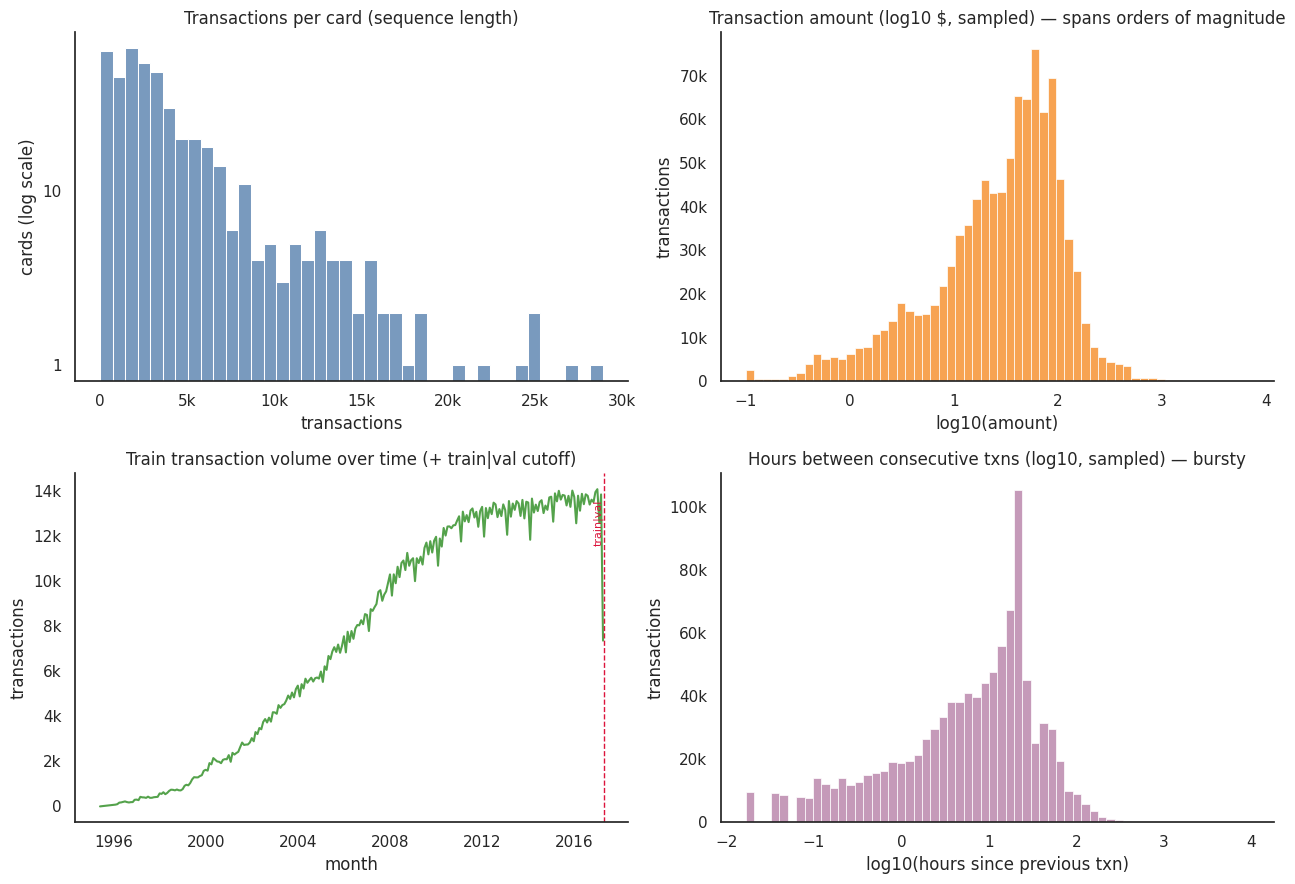

In [7]:
sns.set_theme(style="white", context="notebook")
from matplotlib.ticker import FuncFormatter
from src.tabformer import card_gap_hours

# Human-readable axis numbers: 600000 -> "600k", 2_000_000 -> "2M".
def _human(x, _):
    x = float(x)
    if abs(x) >= 1_000_000: return f"{x / 1e6:g}M"
    if abs(x) >= 1_000:     return f"{x / 1e3:g}k"
    return f"{x:g}"
human = FuncFormatter(_human)

# Per-transaction histograms only need a sample — draw ~1M rows on the workers. The
# inter-transaction gaps need each card's rows together: groupby("card_id").map_groups
# runs one card at a time across the cluster.
frac = min(1.0, 1_000_000 / max(n_txns, 1))
amt_sample = train.random_sample(frac).to_pandas()["amount"]
gap_sample = (train.groupby("card_id").map_groups(card_gap_hours, batch_format="pandas")
              .random_sample(frac).to_pandas()["gap_hours"])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) transactions per card -> motivates the sequence window length (seq_len).
ax = axes[0, 0]
sns.histplot(per_card["txns"], bins=40, color="#4C78A8", ax=ax)
ax.set_yscale("log")
ax.set_title("Transactions per card (sequence length)")
ax.set_xlabel("transactions"); ax.set_ylabel("cards (log scale)")
ax.xaxis.set_major_formatter(human); ax.yaxis.set_major_formatter(human)

# (2) amount spans orders of magnitude -> the tokenizer's fixed dollar-threshold buckets.
ax = axes[0, 1]
log_amt = np.log10(np.clip(np.abs(amt_sample.to_numpy()), 0.1, None))
sns.histplot(log_amt, bins=60, color="#F58518", ax=ax)
ax.set_title("Transaction amount (log10 $, sampled) — spans orders of magnitude")
ax.set_xlabel("log10(amount)"); ax.set_ylabel("transactions")
ax.yaxis.set_major_formatter(human)

# (3) train volume over time, with the train|val temporal cutoff (test = later, not shown).
ax = axes[1, 0]
sns.lineplot(x=pd.PeriodIndex(monthly["month"], freq="M").to_timestamp(),
             y=monthly["txns"].to_numpy(), color="#54A24B", ax=ax)
cut = pd.Timestamp(split_meta["train_cutoff"])
ax.axvline(cut, color="crimson", ls="--", lw=1)
ax.text(cut, ax.get_ylim()[1] * 0.92, "train|val", rotation=90,
        va="top", ha="right", color="crimson", fontsize=8)
ax.set_title("Train transaction volume over time (+ train|val cutoff)")
ax.set_xlabel("month"); ax.set_ylabel("transactions")
ax.yaxis.set_major_formatter(human)

# (4) inter-transaction gaps are bursty -> why the tokenizer carries explicit time fields.
ax = axes[1, 1]
sns.histplot(np.log10(gap_sample.to_numpy()), bins=60, color="#B279A2", ax=ax)
ax.set_title("Hours between consecutive txns (log10, sampled) — bursty")
ax.set_xlabel("log10(hours since previous txn)"); ax.set_ylabel("transactions")
ax.yaxis.set_major_formatter(human)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

Reading the four panels:

1. **Transactions per card.** Activity spans a handful to nearly 50,000 transactions, with a median around 2,500. The pretrain window (Part 3) has to serve both ends: long enough to carry real context for active cards, short enough that the many short-history cards aren't mostly padding.
2. **Transaction amount.** Amounts cluster in the tens of dollars (median ~\$33) with a tail out to thousands. The step from \$10 to \$100 matters like the step from \$100 to \$1,000, so the tokenizer buckets amounts at fixed dollar thresholds (\$0/10/50/100/500/1K/5K) instead of feeding a raw scalar.
3. **Volume over time.** Volume grows through the 2000s and then levels off, so the count-based 80/10/10 cutoffs land in the most recent years — the model trains on the past and is tested on what comes after.
4. **Time between transactions.** The median gap is ~9 hours and a fifth of transactions arrive within an hour of the previous one, with a tail out to days. Ordinal position alone loses that, so each transaction carries explicit hour, day-of-week, and month tokens. (NVIDIA also ships an optional time-delta tokenizer that encodes the gap itself; the blueprint leaves it off, and so do we.)

## Scaling factors

24 million rows is 2.3 GB of CSV — a single machine with pandas can process this dataset, and for a one-off analysis it should. The reason to build the split as a distributed pipeline is what changes when the data grows: at production scale, transactions run to billions of rows, and a pipeline written against one machine's memory gets rewritten.

Each piece of this notebook scales along a different axis. The filter passes are linear in rows and split across parquet shards, so 10× the data means 10× the shard reads — absorbed by adding CPU workers, a cluster-config change rather than a code change. The aggregations are bounded by their output, not their input: daily counts return ~7,000 rows whether the source is 24 million or 24 billion. The per-card work (the gap histogram here, the tokenizer in Part 3) parallelizes across cards, and card count is exactly what grows when an institution's book grows. Nothing in the code names a node count or a data size; the worker pool is the only thing that changes.

## How we measure fraud performance

Only about 1 transaction in 800 is fraudulent, so accuracy is meaningless — a model that flags nothing scores 99.9%. Part 1 explains the two metrics we use instead, Average Precision (AP) and AUC-ROC; the number every later notebook optimizes is AP on the 100K-row test eval set built above.

The stratified eval sets preserve the natural fraud rate, which means the full-scale test set holds only ~112 fraudulent transactions. With that few positives, any single AP score is noisy, which is why Part 6 reports distributions over repeated fits rather than one number.

In [8]:
print(f"normal transactions : {(1 - fraud_rate) * 100:.3f}%")
print(f"fraud transactions  : {fraud_rate * 100:.3f}%")
print(f"imbalance ratio     : ~1 fraud per {int(round(1 / fraud_rate)):,} transactions")

normal transactions : 99.882%
fraud transactions  : 0.118%
imbalance ratio     : ~1 fraud per 851 transactions


## Takeaways

This notebook produced the artifact every later stage reads: the temporal 80/10/10 split plus seeded 100K eval sets, on shared storage, verified identical to NVIDIA's single-GPU reference. The Ray Data pattern it used — parquet shards read in parallel, filters and per-card work on autoscaled CPU workers, small aggregates back to the driver, explicit `__seq__` ordering — is the same one Parts 3 and 5 build on. And the data set the design agenda for Part 3: amounts need bucketing, time needs explicit tokens, and card histories need windowing.

---

## Next

**Part 3 — Tokenize**: turn each card's transaction rows into token sequences with NVIDIA's `FinancialTabularTokenizer` (merchant hashing + category hierarchy + temporal encoding, vocab 6251) and build the pretraining corpus.